## Dataförståelse & EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/historical_data.csv")
print(df.shape)
print(df["is_suspicious"].value_counts())

(12000, 18)
is_suspicious
0    10776
1     1224
Name: count, dtype: int64


In [2]:
print(df.isnull().sum())

id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64


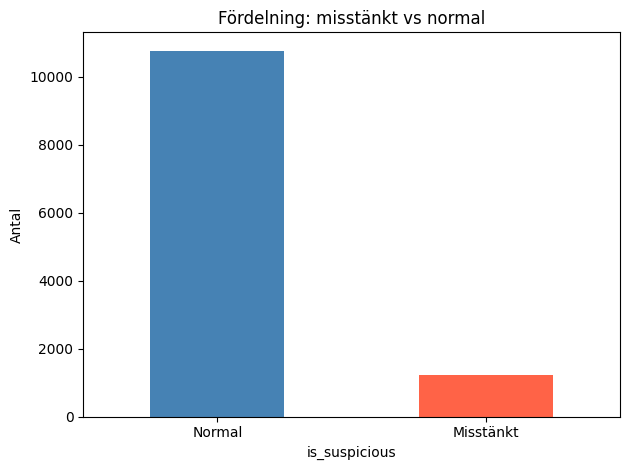

In [3]:
df["is_suspicious"].value_counts().plot(kind="bar", color=["steelblue","tomato"])
plt.title("Fördelning: misstänkt vs normal")
plt.xticks([0,1], ["Normal","Misstänkt"], rotation=0)
plt.ylabel("Antal")
plt.tight_layout()
plt.savefig("figur1_fordelning.png")
plt.show()

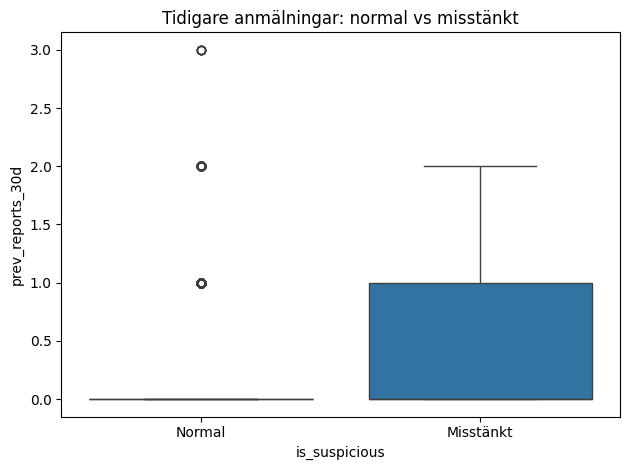

In [4]:
sns.boxplot(x="is_suspicious", y="prev_reports_30d", data=df)
plt.title("Tidigare anmälningar: normal vs misstänkt")
plt.xticks([0,1], ["Normal","Misstänkt"])
plt.tight_layout()
plt.savefig("figur2_anmalningar.png")
plt.show()

** EDA-sammanfattning:
- 12000 rader, 18 kolumner
- 10% misstänkta (1224 av 12000)
- Saknade värden: region (340), price (818), time_to_first_response_min (590)
- Misstänkta konton har tydligt fler tidigare anmälningar än normala konton.

## Train/test + preprocessing

- Vi skapar en train/test-split från historical_data.csv.
- Vi använder stratified split så klasserna fördelas rimligt.
-  Vi bygger pipelines där preprocessing sker på ett sätt som undviker att testdata påverkar träningen (undvik leakage).


In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [6]:

target_column_name = "is_suspicious"
feature_column_names = [col for col in df.columns if col != target_column_name]

X = df[feature_column_names]
y = df[target_column_name]

# Konvertera kategoriska variabler till dummyvariabler
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y)

print("\n================================================\n")
print("Datauppdelning:")
print("Träningsdata:", X_train.shape, y_train.shape)
print("Testdata:", X_test.shape, y_test.shape)  
print("\n================================================\n")
print("Träningsdata - klassfördelning:")
print(y_train.value_counts(normalize=True))
print("\nTestdata - klassfördelning:")
print(y_test.value_counts(normalize=True))




Datauppdelning:
Träningsdata: (9600, 23) (9600,)
Testdata: (2400, 23) (2400,)


Träningsdata - klassfördelning:
is_suspicious
0    0.898021
1    0.101979
Name: proportion, dtype: float64

Testdata - klassfördelning:
is_suspicious
0    0.897917
1    0.102083
Name: proportion, dtype: float64


In [7]:
logreg_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42))
])

tree_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=42))
])

rdf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1))
])

pipelines = {
    "Logistic Regression": logreg_pipeline, 
    "Decision Tree": tree_pipeline,
    "Random Forest": rdf_pipeline
}

## Modellering och jämförelse

- Baseline: Logistic Regression
- Ytterligare modeller: Decision Tree och Random Forest
- Utvärdering: vi använder cross-validation på träningsdatan.
- Metric: ROC-AUC
- Motivering: vår stakeholder (Security Analyst) vill ha en modell som generaliserar bra till ny data. ROC-AUC mäter hur bra modellen kan rangordna misstänkta händelser utan att bero på ett specifikt threshold. Det gör metricen mer robust om beteenden förändras över tid.

In [8]:
from sklearn.model_selection import cross_val_score
import numpy as np

metric = "roc_auc"

print("\n================================================\n")
print("Cross-validation (5 folds)")
print("Metric:", metric)

results = []

for name, pipeline in pipelines.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=metric,
        n_jobs=-1
    )

    mean_score = scores.mean()
    std_score = scores.std()

    print("\n----------------------------------")
    print(name)
    print("Scores:", np.round(scores, 3))
    print("Mean ROC-AUC:", round(mean_score, 3))
    print("Std:", round(std_score, 3))

    results.append({
        "model": name,
        "mean_auc": mean_score
    })



Cross-validation (5 folds)
Metric: roc_auc

----------------------------------
Logistic Regression
Scores: [0.748 0.719 0.733 0.76  0.738]
Mean ROC-AUC: 0.739
Std: 0.014

----------------------------------
Decision Tree
Scores: [0.567 0.56  0.553 0.541 0.548]
Mean ROC-AUC: 0.554
Std: 0.009

----------------------------------
Random Forest
Scores: [0.744 0.727 0.743 0.734 0.735]
Mean ROC-AUC: 0.737
Std: 0.006


In [9]:
results_df = pd.DataFrame(results)

print("\n================================================\n")
print("Modelljämförelse")

results_df.sort_values("mean_auc", ascending=False)



Modelljämförelse


,model,mean_auc
0,Logistic Regression,0.739434
2,Random Forest,0.736625
1,Decision Tree,0.553976


** Modellering och jämförelse - sammanfattning:

- Vi jämför tre modeller: Logistic Regression, Decision Tree och Random Forest.
- Cross-validation (5 folds) används för att utvärdera modellerna med metric ROC-AUC.
- Resultaten visar att Logistic Regression presterar bäst, tätt följd av Random Forest, medan Decision Tree presterar betydligt sämre.
- Vi väljer därför Logistic Regression som slutlig modell eftersom den ger högst genomsnittlig ROC-AUC.
- En enklare modell kan också vara mer stabil över tid, vilket är viktigt eftersom beteenden i systemet kan förändras och modellen behöver generalisera till nya typer av aktivitet.

In [35]:
chosen_model_name = "Logistic Regression"
print("Tuning:", chosen_model_name)

param_grid = [
     # L2 (Ridge)
    {
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        "model__solver": ["lbfgs"],
        "model__l1_ratio": [0]
    },
    # L1 (Lasso)
    {
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        "model__solver": ["saga"],
        "model__l1_ratio": [1]
    }
]

grid = GridSearchCV(
    estimator=pipelines[chosen_model_name],
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameter:", grid.best_params_)
print("Best roc/auc  :", grid.best_score_)

Tuning: Logistic Regression
Best parameter: {'model__C': 0.1, 'model__l1_ratio': 1, 'model__solver': 'saga'}
Best roc/auc  : 0.7406900958239


## Optimering av Logistic Regression

Vi körde GridSearchCV på träningsdatan med 5-fold cross-validation och ROC-AUC som mätvärde.
Vi testade olika C(0.01 upp till 100) för att se hur mycket regularisering som passade bäst, samt Ridge vs Lasso.

Bäst blev:
- C = 0.1, l1_ratio = 1, solver = saga med ROC-AUC på 0.7406~
- Marginellt bättre än lbfgs med ett ROC-AUC värde på 0.7394~

Optimeringen gav bara en liten förbättring eftersom modellen redan var nära sitt tak, så mer tuning ger begränsad effekt.